# Lab Assignment: Exploratory Data Analysis with Pandas

**Goal**: Implement data manipulation and visualization using only Pandas-native functions.

**Note**: Use the provided synthetic data to complete the questions. Focus on using `df.plot()` and other Pandas-specific methods.

In [1]:
import pandas as pd
import numpy as np

# Setup for the lab
np.random.seed(42)
n = 200
data = {
    'product_id': range(1, n + 1),
    'category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Groceries'], n),
    'price': np.random.uniform(10, 500, n).round(2),
    'units_sold': np.random.randint(1, 100, n),
    'rating': np.random.uniform(1, 5, n).round(1),
    'in_stock': np.random.choice([True, False], n)
}
df = pd.DataFrame(data)
print('Dataset prepared for assignment.')

Dataset prepared for assignment.


### Question 1: Initial Exploration

**Task**: Use Pandas functions to identify the total number of rows/columns, the data types of each column, and the count of missing values.

**Hints**:
- Check `.shape` for dimensions.
- Use `.info()` for types and null counts.
- Use `.describe()` for a statistical overview.

In [2]:
import pandas as pd
import numpy as np

# Setup
np.random.seed(42)
n = 200
data = {
    'product_id': range(1, n + 1),
    'category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Groceries'], n),
    'price': np.random.uniform(10, 500, n).round(2),
    'units_sold': np.random.randint(1, 100, n),
    'rating': np.random.uniform(1, 5, n).round(1),
    'in_stock': np.random.choice([True, False], n)
}
df = pd.DataFrame(data)

# 1. Dimensions
print("Shape:", df.shape)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# 2. Data types and null counts
print("--- Info ---")
df.info()

# 3. Missing values explicitly
print("\nMissing values per column:")
print(df.isnull().sum())

# 4. Statistical overview
print("\n--- Descriptive Statistics ---")
print(df.describe())

Shape: (200, 6)
Rows: 200, Columns: 6

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   product_id  200 non-null    int64  
 1   category    200 non-null    str    
 2   price       200 non-null    float64
 3   units_sold  200 non-null    int32  
 4   rating      200 non-null    float64
 5   in_stock    200 non-null    bool   
dtypes: bool(1), float64(2), int32(1), int64(1), str(1)
memory usage: 7.4 KB

Missing values per column:
product_id    0
category      0
price         0
units_sold    0
rating        0
in_stock      0
dtype: int64

--- Descriptive Statistics ---
       product_id       price  units_sold      rating
count  200.000000  200.000000  200.000000  200.000000
mean   100.500000  258.781200   50.145000    3.030500
std     57.879185  143.422716   29.963864    1.220396
min      1.000000   12.480000    1.000000    1.000000
25%     50.

### Question 2: Advanced Filtering

**Task**: Create a new DataFrame containing only the 'Electronics' and 'Clothing' categories where the `price` is above the average price of the entire dataset.

**Hints**:
- Use `.mean()` to calculate the threshold.
- Use boolean indexing or `.query()` for filtering.

In [11]:
avg_price = df['price'].mean()
print(f"Average price: ${avg_price:.2f}")

    
filtered_df = df.query("category in ['Electronics', 'Clothing'] and price > @avg_price")

print(f"\nFiltered DataFrame shape: {filtered_df.shape}")
print(f"Categories present: {filtered_df['category'].unique()}")
print(f"Min price in result: ${filtered_df['price'].min():.2f}")
print(f"\n{filtered_df.head(10)}")

Average price: $258.78

Filtered DataFrame shape: (50, 6)
Categories present: <StringArray>
['Electronics', 'Clothing']
Length: 2, dtype: str
Min price in result: $260.93

    product_id     category   price  units_sold  rating  in_stock
7            8  Electronics  380.22          16     2.5     False
15          16  Electronics  437.02          58     3.2     False
20          21     Clothing  405.65          23     1.0     False
21          22  Electronics  449.08           9     2.9      True
26          27     Clothing  410.83          34     4.0      True
27          28     Clothing  431.76          96     3.3     False
34          35     Clothing  472.03          63     1.0     False
37          38  Electronics  354.48          93     4.6     False
57          58  Electronics  383.19          48     1.8      True
59          60  Electronics  366.83          39     2.4     False


### Question 3: Grouping and Aggregation

**Task**: Find the total revenue (Price * Units Sold) per category. Sort the result from highest to lowest revenue.

**Hints**:
- Create a new column first.
- Use `.groupby()` and `.sum()`.
- Use `.sort_values()`.

In [12]:
# 1. Create the revenue column
df['revenue'] = df['price'] * df['units_sold']

# 2. Group by category and sum revenue
revenue_by_category = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 3. Format and display
revenue_by_category.columns = ['category', 'total_revenue']
revenue_by_category['total_revenue'] = revenue_by_category['total_revenue'].round(2)

print(revenue_by_category)

      category  total_revenue
0    Groceries      776467.68
1         Home      716885.15
2  Electronics      561996.70
3     Clothing      528857.79


### Question 4: Data Visualization (Pandas Only)

**Task**: Generate the following plots using the `df.plot()` method:
1. A **bar chart** showing the average rating per category.
2. A **scatter plot** relating 'price' to 'units_sold'.
3. A **histogram** of the 'price' distribution.

**Hints**:
- For the bar chart, you must aggregate the data first.
- Use the `kind` parameter (e.g., `kind='bar'`, `kind='scatter'`, `kind='hist'`).

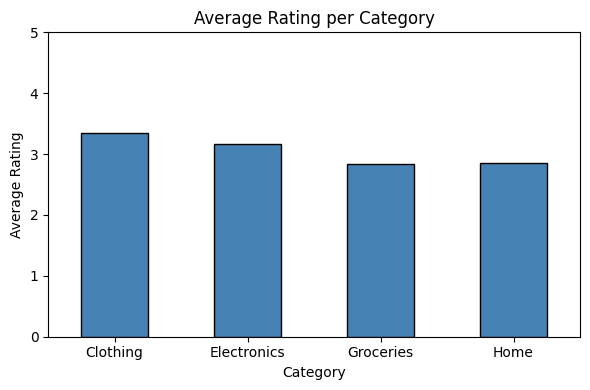

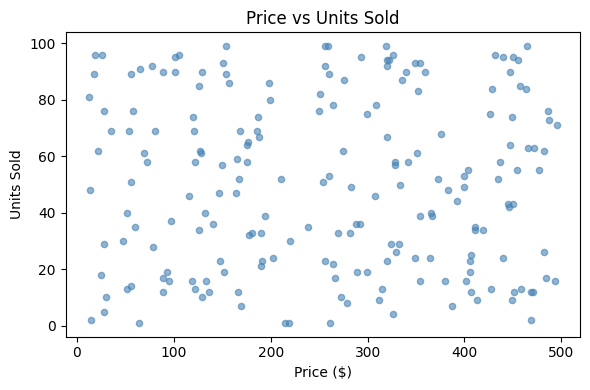

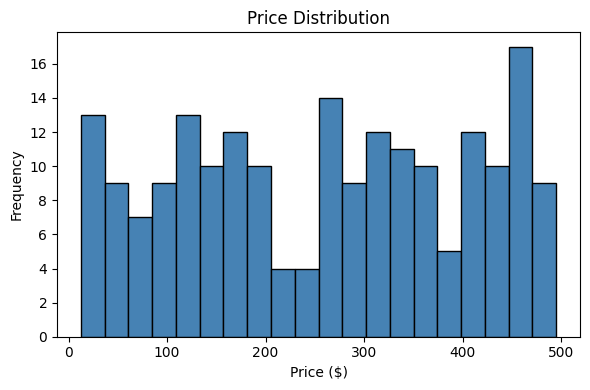

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setup
np.random.seed(42)
n = 200
data = {
    'product_id': range(1, n + 1),
    'category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Groceries'], n),
    'price': np.random.uniform(10, 500, n).round(2),
    'units_sold': np.random.randint(1, 100, n),
    'rating': np.random.uniform(1, 5, n).round(1),
    'in_stock': np.random.choice([True, False], n)
}
df = pd.DataFrame(data)

# --- Plot 1: Bar chart — Average rating per category ---
avg_rating = df.groupby('category')['rating'].mean().round(2)

avg_rating.plot(
    kind='bar',
    title='Average Rating per Category',
    xlabel='Category',
    ylabel='Average Rating',
    color='steelblue',
    edgecolor='black',
    rot=0,
    ylim=(0, 5),
    figsize=(6, 4)
)
plt.tight_layout()
plt.show()

# --- Plot 2: Scatter plot — Price vs Units Sold ---
df.plot(
    kind='scatter',
    x='price',
    y='units_sold',
    title='Price vs Units Sold',
    xlabel='Price ($)',
    ylabel='Units Sold',
    color='steelblue',
    alpha=0.6,
    figsize=(6, 4)
)
plt.tight_layout()
plt.show()

# --- Plot 3: Histogram — Price distribution ---
df['price'].plot(
    kind='hist',
    title='Price Distribution',
    xlabel='Price ($)',
    ylabel='Frequency',
    bins=20,
    color='steelblue',
    edgecolor='black',
    figsize=(6, 4)
)
plt.tight_layout()
plt.show()

### Question 5: Pivot Tables

**Task**: Create a pivot table that shows the **average units_sold** for each `category`, broken down by whether the items are `in_stock` or not.

**Hints**:
- Use `df.pivot_table()`.
- Set `index='category'`, `columns='in_stock'`, and `values='units_sold'`.
- Use `aggfunc='mean'`.

In [18]:
# Create the pivot table
pivot = df.pivot_table(
    index='category',
    columns='in_stock',
    values='units_sold',
    aggfunc='mean'
).round(2)

# Rename columns for clarity
pivot.columns = ['Out of Stock', 'In Stock']
pivot.columns.name = None

print(pivot)

             Out of Stock  In Stock
category                           
Clothing            47.50     47.90
Electronics         52.08     28.14
Groceries           54.10     59.68
Home                52.27     54.88


### Question 6: Binning and Custom Mapping

**Task**: Create a new column called `price_bracket`. If the price is < 100, label it 'Budget'; if 100-300, label it 'Mid-Range'; if > 300, label it 'Premium'. Then, count how many products fall into each bracket.

**Hints**:
- Use `pd.cut()` to create the bins.
- Use `.value_counts()` to see the distribution.

In [19]:
# Create price_bracket column using pd.cut()
df['price_bracket'] = pd.cut(
    df['price'],
    bins=[0, 100, 300, 500],
    labels=['Budget', 'Mid-Range', 'Premium']
)

# Count products per bracket
bracket_counts = df['price_bracket'].value_counts().sort_index()
print(bracket_counts)

price_bracket
Budget       35
Mid-Range    79
Premium      86
Name: count, dtype: int64
